# 02 — EDA confiable y preparación para customer journey discovery

Consultas exactas sobre los 13 datasets verificados en 00/01. Fuentes: reports/profiling/SUMMARY.md, inventory_columns.csv, datasets.csv y source_manifest.json. No se repite el profiling.

DuckDB mantiene proyecciones comprimidas en .tmp/eda, con firmas de las fuentes y validación de filas. pandas recibe solamente tablas agregadas; los 15,6 millones de eventos digitales no se materializan en pandas. Se preservan nulos y extremos. Las salidas completas se guardan en reports/eda y se muestran extractos legibles aquí. Etapa 03 queda pendiente.

In [1]:
from pathlib import Path
import sys
root = Path.cwd().resolve()
if not (root / 'AGENTS.md').exists():
    root = root.parent
assert (root / 'AGENTS.md').exists()
sys.path.insert(0, str(root))
import pandas as pd
from IPython.display import display, Markdown, Image
from src.eda_core import OUT, FIG, start, finish
from src import eda_readiness as ready, eda_domains as domain, eda_outputs as output
def show(*names, limit=30):
    for name in names:
        display(Markdown('**' + name + '**'))
        display(pd.read_csv(OUT / name).head(limit))
con, context = start()
display(context)

Verificando SHA-256 de fuentes contra el profiling existente


Cache verificada: branches


Cache verificada: call_center_interactions


Cache verificada: call_transcripts


Cache verificada: campaign_sends


...

Cache verificada: products


Cache verificada: satisfaction_surveys


Cache verificada: service_agents


Cache verificada: transactions


{'execution_timestamp': '2026-10-01T00:43:28.375308-05:00',
 'feature_cutoff_inclusive': '2026-06-17',
 'age_reference_date': '2026-06-17',
 'source_manifest_sha256': 'edaa6b4db2c0053ead935ffc30d0d2928d0d4769bfa8e7b9d880e57043827074',
 'source_files': 7671,
 'method': 'Exact DuckDB; no sampling, imputation or outlier removal',
 'satisfaction_policy': 'avg_satisfaction/latest_satisfaction are CSAT only',
 'feature_policy': 'Events and dated outcomes <= cutoff; ambiguous snapshot attributes excluded'}

## 0. EDA Readiness & Semantic Validation

### 0.1 Transaction → Product → Customer
### 0.2 Transcript → Interaction
### 0.3 Survey → Interaction
### 0.4 Complaint → Product → Customer

Primero se comprueba unicidad de los destinos. Los totales distinguen referencias elegibles, enlazadas, huérfanas y coincidencia de propietario/agente. El porcentaje consistente usa referencias no nulas como denominador. Ejemplos de discrepancias contienen hashes truncados de los IDs. Ninguna discrepancia se corrige.

In [2]:
ready.semantic(con)
show('semantic_validation.csv','semantic_validation_examples.csv','branch_validation.csv')

Readiness semántica completada


**semantic_validation.csv**

,validation,total,eligible,linked,orphan,inconsistent,consistent,consistent_pct
0,transaction_product_customer,4425008,4425008,4425008,0,0,4425008,100.0
1,transcript_customer,171321,171321,171321,0,0,171321,100.0
2,transcript_agent,171321,171321,171321,0,0,171321,100.0
3,survey_customer,212759,212759,212759,0,0,212759,100.0
4,survey_agent,212759,212759,212759,0,0,212759,100.0
5,complaint_product_customer,67095,44570,44570,0,44570,0,0.0


**semantic_validation_examples.csv**

,validation,record_hash,source_value_hash,target_value_hash
0,complaint_product_customer,d1bf18bbb629c204,dce56173080025e7,0dc2673283fbea96
1,complaint_product_customer,cd14813728dcff47,7f0db4110341638a,ef884e3fa13a9a37
2,complaint_product_customer,3dc910a86432a279,11a45e7ffe8abfbf,8ea252265d9af199
3,complaint_product_customer,290157f9a19225b6,044c90db49a545b5,2f89b48f74062dad
4,complaint_product_customer,6314e5dce5cb27c0,497abe76dde3b05a,97310aa238bf5cfa


**branch_validation.csv**

,relation,total,null_reference,known,orphan
0,products.opening_branch_id,400000,0,400000,0
1,transactions.branch_id,4425008,3037076,1387932,0


### 0.5 Temporal consistency
### 0.6 Observation window

La fecha real de ejecución está en analysis_context.json. El horizonte observado se deriva de fechas de eventos; transcripts solo tiene process_date y se etiqueta como cobertura de proceso. customers/products.last_updated se excluyen.

process_date es una fecha de proceso con granularidad de día. Se comparan días antes/igual/después, y se informa diferencia nominal de horas contra medianoche: no equivale a latencia real. Los registros posteriores a un día se señalan como candidatos a llegada tardía, sin asumir error.

Las features usan el último día de proceso compartido y excluyen eventos/resultados posteriores. Fechas de cierre y conversión pueden extenderse más allá de la ventana primaria: se muestran por separado.

In [3]:
ready.temporal(con)
show('temporal_coverage.csv','temporal_delays.csv','lifecycle_windows.csv','dimension_date_windows.csv')

Readiness temporal completada


**temporal_coverage.csv**

,dataset,basis,min_timestamp,max_timestamp,min_date,max_date,active_days,calendar_days,days_without_records
0,transactions,transaction_date,2023-06-17 06:01:30,2026-06-18 05:59:41,2023-06-17,2026-06-18,1098,1098,0
1,digital_events,event_date,2023-06-17 06:02:03,2026-06-18 06:04:05,2023-06-17,2026-06-18,1098,1098,0
2,call_center_interactions,interaction_date,2023-06-17 08:03:26,2026-06-18 07:58:13,2023-06-17,2026-06-18,1098,1098,0
3,call_transcripts,process_date only; no independent event timestamp,2023-06-17 00:00:00,2026-06-17 00:00:00,2023-06-17,2026-06-17,1097,1097,0
4,complaints,creation_date,2023-06-17 08:07:05,2026-06-18 07:56:52,2023-06-17,2026-06-18,1098,1098,0
5,satisfaction_surveys,survey_date,2023-06-17 09:29:20,2026-06-19 06:54:58,2023-06-17,2026-06-19,1099,1099,0
6,campaign_sends,send_date,2023-07-01 06:00:42,2026-06-18 05:59:53,2023-07-01,2026-06-18,1084,1084,0


**temporal_delays.csv**

,dataset,total,processed_before_day,processed_same_day,processed_after_day,potential_late_over_1d,min_lag_days,max_lag_days,median_lag_days,p95_lag_days,nominal_median_hours
0,transactions,4425008,1106307,3318701,0,0,-1,0,0.0,0.0,-18.003056
1,digital_events,15620994,3930816,11690178,0,0,-1,0,0.0,0.0,-18.045833
2,call_center_interactions,686296,228318,457978,0,0,-1,0,0.0,0.0,-19.982361
3,complaints,67095,22585,44510,0,0,-1,0,0.0,0.0,-20.088056
4,satisfaction_surveys,212759,169092,43667,0,0,-2,0,-1.0,0.0,-32.477778
5,campaign_sends,1746801,436429,1310372,0,0,-1,0,0.0,0.0,-17.990833


**lifecycle_windows.csv**

,dataset,field,min_timestamp,max_timestamp,observed
0,complaints,assignment_date,2023-06-17 22:26:12,2026-06-19 03:56:52,43967
1,complaints,first_response_date,2023-06-18 03:37:40,2026-06-20 22:42:19,40853
2,complaints,resolution_date,2023-06-20 07:10:42,2026-07-18 06:07:57,15349
3,complaints,closing_date,2023-06-26 11:38:44,2026-07-18 22:15:16,2481
4,campaign_sends,open_date,2023-07-01 07:44:22,2026-06-25 03:30:02,487309
5,campaign_sends,click_date,2023-07-01 21:57:26,2026-06-24 23:51:59,97793
6,campaign_sends,conversion_date,2023-07-03 12:56:27,2026-06-26 08:26:49,9799


**dimension_date_windows.csv**

,dataset,date_basis,min_date,max_date,active_days,calendar_days,days_without_records
0,customers,registration_date,2018-06-18,2026-06-17,2922,2922,0
1,products,opening_date,2018-06-18,2026-06-17,2922,2922,0
2,branches,branch_opening_date,1990-01-03,2023-05-11,346,12182,11836
3,service_agents,hire_date,2013-06-20,2026-03-17,1055,4654,3599
4,marketing_campaigns,start_date,2023-07-01,2026-06-14,186,1080,894
5,daily_exchange_rates,date,2023-06-17,2026-06-17,1097,1097,0


## 1. Dataset coverage over time

Se calculan registros diarios/mensuales, gaps internos y cambios de volumen al menos x2 o /2 frente al día observado anterior. Es una heurística descriptiva; los límites pueden ser días parciales. Se comprueba la relación entre sufijo del archivo, fecha de proceso y fecha del evento. Los gráficos mensuales se generan en la sección 14, después de las validaciones.

In [4]:
show('partition_day_check.csv','temporal_gaps.csv','abrupt_volume_changes.csv','coverage_monthly.csv')

**partition_day_check.csv**

,dataset,files,parseable_filenames,distinct_file_days,files_matching_process_day,files_with_single_event_day,events_outside_filename_day
0,transactions,1097,1097,1097,1097,0,1106307
1,digital_events,1097,1097,1097,1097,0,3930816
2,call_center_interactions,1097,1097,1097,1097,0,228318
3,call_transcripts,1097,1097,1097,1097,1097,0
4,complaints,1097,1097,1097,1097,0,22585
5,satisfaction_surveys,1097,1097,1097,1097,0,169092
6,campaign_sends,1083,1083,1083,1083,0,436429


**temporal_gaps.csv**

,dataset,day


**abrupt_volume_changes.csv**

,dataset,day,n,previous_n,ratio,position
0,transactions,2026-06-18,1352,5244,0.257818,boundary
1,digital_events,2023-07-02,9173,19091,0.480488,interior
2,digital_events,2023-07-09,17452,8466,2.061422,interior
3,digital_events,2023-08-13,10117,23371,0.432887,interior
4,digital_events,2023-08-15,18030,8339,2.162130,interior
5,digital_events,2023-10-02,22148,8839,2.505713,interior
6,digital_events,2023-10-07,10105,20742,0.487176,interior
7,digital_events,2023-10-26,25979,12615,2.059374,interior
8,digital_events,2023-10-29,8774,19719,0.444952,interior
9,digital_events,2023-10-31,25104,9173,2.736727,interior


**coverage_monthly.csv**

,dataset,month,records
0,call_center_interactions,2023-06,9012
1,call_center_interactions,2023-07,19261
2,call_center_interactions,2023-08,19729
3,call_center_interactions,2023-09,18349
4,call_center_interactions,2023-10,19168
5,call_center_interactions,2023-11,18734
6,call_center_interactions,2023-12,19141
7,call_center_interactions,2024-01,18947
8,call_center_interactions,2024-02,18474
9,call_center_interactions,2024-03,18952


## 2. Customer & product base

Edad referida al corte de observación, no a la fecha de ejecución. Geografía y segmentos describen atributos del snapshot, sin atribuirles vigencia histórica. Ingreso se presenta por país porque la moneda no está documentada. Balances/límites se segmentan por currency.

registration_branch_id no se utiliza para joins. Los productos se describen por tipo, estado, apertura, morosidad y última transacción; opening_branch_id fue revalidado en readiness.

In [5]:
domain.customers_products(con, context)
show('customer_numeric.csv','customer_income_by_country.csv','customer_categories.csv','product_categories.csv','product_money_by_currency.csv','product_numeric.csv','products_per_customer.csv','product_date_ranges.csv')

Clientes y productos completados


**customer_numeric.csv**

,dataset,variable,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,customer_age,age,150000,150000,0,20.0,83.0,51.988787,52.0,77.0,80.0,83.0
1,customer_age,credit_score,150000,127508,0,422.0,850.0,647.098362,631.0,761.0,802.0,850.0


**customer_income_by_country.csv**

,dataset,variable,country,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,customers,estimated_monthly_income,México,74907,59968,0,5100.28,4.759817e+05,7.878293e+04,39219.570,1.741021e+05,3.085751e+05,4.435264e+05
1,customers,estimated_monthly_income,Argentina,29842,23864,0,105127.04,9.796686e+06,1.609498e+06,801955.375,3.572774e+06,6.340040e+06,9.099718e+06
2,customers,estimated_monthly_income,Colombia,45251,36135,0,1200127.28,1.118951e+08,1.838072e+07,9192465.520,4.071714e+07,7.225298e+07,1.036447e+08


...

,dataset,variable,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,products,days_past_due,400000,125350,0,0.0,180.0,12.341045,0.0,30.00,90.00,180.00
1,products,interest_rate,400000,359934,0,0.0,45.0,9.984632,2.2,34.23,39.64,43.92


**products_per_customer.csv**

,customers,median_products,p90,p95,p99,maximum
0,150000,2.0,5.0,6.0,7.0,12


**product_date_ranges.csv**

,earliest_opening,latest_opening,earliest_last_transaction,latest_last_transaction,no_last_transaction
0,2018-06-18,2026-06-17,2018-06-21 17:07:15,2026-06-17 23:17:43,94277


## 3. Transactions

Comparaciones globales en amount_usd; amount se resume únicamente por currency. Se incluyen medianas y p90/p95/p99, actividad por cliente/producto, categorías, merchants y cobertura de branch. El histograma logarítmico conserva todos los montos positivos/negativos; ceros/nulos se cuentan aparte porque no tienen logaritmo.

In [6]:
domain.transactions(con, context)
show('transaction_numeric.csv','transaction_amount_by_currency.csv','transactions_per_customer_id.csv','transactions_per_product_id.csv','transaction_categories.csv','transaction_merchant_coverage.csv','transaction_top_merchants.csv')

Transacciones completadas


**transaction_numeric.csv**

,dataset,variable,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,transactions,amount_usd,4425008,1887552,0,5.0,9999.96,1675.074620,466.69,5113.063,7554.5035,9506.7149
1,transactions,fraud_score,4425008,3539851,0,0.0,99.99,15.031166,15.01,27.020,28.5200,29.7200


**transaction_amount_by_currency.csv**

,dataset,variable,currency,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,transactions,amount,ARS,792585,792585,0,1750.05,3499939.11,5.863337e+05,163284.79,1.791472e+06,2.643280e+06,3.326341e+06
1,transactions,amount,COP,1194444,1194444,0,20006.90,39999828.48,6.697011e+06,1867136.48,2.041605e+07,3.021782e+07,3.803013e+07
2,transactions,amount,USD,2437979,2437979,0,5.00,9999.98,1.675653e+03,467.08,5.119924e+03,7.551060e+03,9.509247e+03


...

,dataset,variable,category,records,pct
0,transactions,transaction_type,Purchase,1083406,24.483707
1,transactions,transaction_type,Withdrawal,964673,21.800480
2,transactions,transaction_type,Transfer,896438,20.258449
3,transactions,transaction_type,Payment,738964,16.699721
4,transactions,transaction_type,Deposit,609409,13.771930
5,transactions,transaction_type,Adjustment,132118,2.985712
6,transactions,transaction_category,NaN,2693520,60.870398
7,transactions,transaction_category,Food,432468,9.773270
8,transactions,transaction_category,Services,345370,7.804958
9,transactions,transaction_category,Other,260518,5.887402


**transaction_merchant_coverage.csv**

,transactions,merchant_known,category_known,distinct_merchants
0,4425008,1029234,1028793,24


**transaction_top_merchants.csv**

,merchant_name,transactions,median_usd,total_usd
0,Super Ahorro,64527,253.210,6941088.67
1,Restaurante El Buen Sabor,64370,254.030,6967715.07
2,Tienda Don José,64249,251.765,6871207.24
3,Mercado Central,63912,252.190,6945914.97
4,Empresa Telefónica,51464,253.450,5537678.51
5,Cable TV,51430,251.955,5509316.11
6,Servicios Públicos,51250,249.685,5447671.52
7,Internet Plus,51002,250.490,5478506.23
8,Estación de Servicio,39019,254.815,4226659.83
9,Uber,38881,250.700,4137189.15


## 4. Digital behavior

IDENTIFIED DIGITAL EVENTS: customer_id IS NOT NULL.
ANONYMOUS DIGITAL EVENTS: customer_id IS NULL.

Distribuciones separadas por identificación; product_id se trata como cobertura secundaria. Las sesiones se agrupan por el session_id registrado; su intervalo observado no mide necesariamente la duración real. Se cuentan sesiones de múltiples clientes y mixtas antes de proponer su uso en journeys.

In [7]:
domain.digital(con, context)
show('digital_coverage.csv','digital_events_per_customer.csv','digital_identified_categories.csv','digital_anonymous_categories.csv','digital_sessions_numeric.csv','digital_sessions_quality.csv')

Digital identificado, anónimo y sesiones completados


**digital_coverage.csv**

,events,identified,anonymous,identified_pct,anonymous_pct,identified_customers,product_known,product_known_pct,session_known
0,15620994,11875548,3745446,76.022998,23.977002,149997,1440338,9.220527,15620994


**digital_events_per_customer.csv**

,identified_customers,median,p90,p95,p99,maximum
0,149997,77.0,116.0,128.0,152.0,238


...

,dataset,variable,category,records,pct
0,digital_events,event_type,PageView,1431772,38.227010
1,digital_events,event_type,Click,858970,22.933717
2,digital_events,event_type,Logout,583831,15.587756
3,digital_events,event_type,Login,583821,15.587489
4,digital_events,event_type,FormSubmit,143343,3.827128
5,digital_events,event_type,Error,86060,2.297724
6,digital_events,event_type,Purchase,57649,1.539176
7,digital_events,event_category,Authentication,1167652,31.175246
8,digital_events,event_category,Navigation,948701,25.329453
9,digital_events,event_category,Product,908123,24.246058


**digital_sessions_numeric.csv**

,dataset,variable,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,eda_sessions,events,1837415,1837415,0,2.0,15.0,8.501614,9.0,14.0,15.0,15.0
1,eda_sessions,observed_span_seconds,1837415,1837415,0,5.0,699.0,243.834856,240.0,433.0,470.0,532.0
2,eda_sessions,identified_customers,1837415,1837415,0,0.0,1.0,0.800239,1.0,1.0,1.0,1.0


**digital_sessions_quality.csv**

,sessions,singleton_sessions,multi_customer_sessions,anonymous_only_sessions,mixed_identity_sessions
0,1837415,0,0,367044,498785


## 5. Service interactions

La tabla incluye llamadas entrantes/salientes, chat, email y video. Duración/espera en segundos con mediana y percentiles, más histogramas de la cola completa. Sentimientos negativos usan las categorías reales Negativo y Muy Negativo.

In [8]:
domain.service(con, context)
show('service_numeric.csv','service_per_customer.csv','service_categories.csv')

Interacciones de servicio completadas


**service_numeric.csv**

,dataset,variable,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,call_center_interactions,duration_seconds,686296,590062,0,30.0,1204.0,321.454545,291.00,538.00,614.00,762.00
1,call_center_interactions,wait_time_seconds,686296,480678,0,0.0,424.0,119.937081,119.00,196.00,218.00,259.00
2,call_center_interactions,sentiment_score,686296,686296,0,-1.0,1.0,-0.036937,-0.02,0.44,0.62,0.89


**service_per_customer.csv**

,customers,median_interactions,p95_interactions,maximum
0,148443,4.0,8.0,18


**service_categories.csv**

,dataset,variable,category,records,pct
0,call_center_interactions,interaction_type,Inbound Call,480678,70.039458
1,call_center_interactions,interaction_type,Outbound Call,102572,14.945738
2,call_center_interactions,interaction_type,Chat,68691,10.008947
3,call_center_interactions,interaction_type,Email,27543,4.013283
4,call_center_interactions,interaction_type,Video,6812,0.992575
5,call_center_interactions,contact_reason,Transaccional,240056,34.978493
6,call_center_interactions,contact_reason,Producto,150863,21.982206
7,call_center_interactions,contact_reason,Queja,117021,17.051097
8,call_center_interactions,contact_reason,Técnico,102899,14.993385
9,call_center_interactions,contact_reason,Comercial,54879,7.996404


## 6. Transcript coverage & representativeness

La cobertura se calcula sobre todas las interacciones y también sobre llamadas entrantes/salientes. Se usa presencia real del transcript, no solo un flag. Comparaciones WITH/WITHOUT: duración, espera, sentimiento, motivo, canal, agente y mes. Diferencias observadas no prueban mecanismo causal de selección; semejanza no descarta sesgo.

Después se describen caracteres y palabras (separación por espacios). No se exporta texto ni se ejecutan modelos de lenguaje.

In [9]:
domain.transcripts(con)
show('transcript_coverage.csv','transcript_selection_numeric.csv','transcript_selection_categories.csv','transcript_selection_monthly.csv','transcript_text_lengths.csv')

Cobertura y selección de transcripts completadas


**transcript_coverage.csv**

,n_interactions,n_interactions_with_transcript,interaction_coverage_pct,n_calls,n_calls_with_transcript,call_coverage_pct,child_rows
0,686296,171321,24.963135,583250,145577,24.959623,171321


**transcript_selection_numeric.csv**

,dataset,variable,has_child,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,selected_calls,duration_seconds,True,171321,147292,0,30.0,1151.0,321.464866,290.00,539.00,614.00,764.00
1,selected_calls,duration_seconds,False,514975,442770,0,30.0,1204.0,321.451112,291.00,538.00,614.00,761.00
2,selected_calls,wait_time_seconds,True,171321,120212,0,0.0,424.0,119.781070,119.00,196.00,218.00,260.00
3,selected_calls,wait_time_seconds,False,514975,360466,0,0.0,421.0,119.989109,119.00,196.00,218.00,259.00
4,selected_calls,sentiment_score,True,171321,171321,0,-1.0,1.0,-0.037993,-0.02,0.43,0.62,0.89
5,selected_calls,sentiment_score,False,514975,514975,0,-1.0,1.0,-0.036586,-0.02,0.44,0.62,0.89


...

,variable,category,interactions,with_child,coverage_pct,pct_with_group,pct_without_group
0,contact_reason,Transaccional,240056,59786,24.905022,34.897065,35.005583
1,contact_reason,Producto,150863,37658,24.961720,21.980960,21.982621
2,contact_reason,Queja,117021,29198,24.951077,17.042861,17.053838
3,contact_reason,Técnico,102899,25691,24.967201,14.995827,14.992572
4,contact_reason,Comercial,54879,13808,25.160808,8.059724,7.975339
5,contact_reason,Retención,20578,5180,25.172514,3.023564,2.990048
6,channel,Phone,583250,145577,24.959623,84.973237,84.989174
7,channel,Email,27543,6953,25.244164,4.058463,3.998252
8,channel,App,26364,6560,24.882415,3.829069,3.845624
9,channel,WhatsApp,22888,5692,24.868927,3.322418,3.339191


**transcript_selection_monthly.csv**

,month,interactions,with_child,coverage_pct
0,2023-06-01,9012,2211,24.533955
1,2023-07-01,19261,4842,25.138882
2,2023-08-01,19729,4951,25.095038
3,2023-09-01,18349,4586,24.993188
4,2023-10-01,19168,4766,24.864357
5,2023-11-01,18734,4653,24.837194
6,2023-12-01,19141,4759,24.862860
7,2024-01-01,18947,4737,25.001319
8,2024-02-01,18474,4564,24.704991
9,2024-03-01,18952,4769,25.163571


**transcript_text_lengths.csv**

,dataset,variable,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,transcript_lengths,chars,171321,171321,0,219.0,451.0,277.841403,231.0,400.0,412.0,428.0
1,transcript_lengths,words,171321,171321,0,36.0,77.0,44.753095,37.0,64.0,67.0,71.0


## 7. Complaints

origin_interaction_id está completamente nulo en el profiling; no hay un join observado a la interacción de origen. Estado, prioridad, asignación y tiempos se analizan tal como se registran. Nulos de resolución/cierre se calculan por estado.

El estado snapshot no permite reconstruir qué estaba abierto en el corte. open_complaint_count queda NULL explícitamente; se ofrece no_observed_resolution_by_cutoff_count como otra variable, sin equipararla a abierto. Las resoluciones posteriores al corte no entran en las features.

In [10]:
domain.complaints(con, context)
show('complaint_conditional_nulls.csv','complaint_lifecycle.csv','complaint_resolution_by_status.csv','complaint_money_by_currency.csv','complaint_categories.csv')

Reclamos y nulos condicionales completados


**complaint_conditional_nulls.csv**

,status,records,assignment_null,first_response_null,resolution_null,closing_null,resolution_null_pct,closing_null_pct,origin_interaction_null
0,Closed,2609,132,109,140,128,5.366041,4.906094,2609
1,Escalated,3321,143,3321,3321,3321,100.000000,100.000000,3321
2,In Process,26823,1341,1331,26823,26823,100.000000,100.000000,26823
3,Open,20125,20125,20125,20125,20125,100.000000,100.000000,20125
4,Rejected,705,705,705,705,705,100.000000,100.000000,705
5,Resolved,13512,682,651,632,13512,4.677324,100.000000,13512


**complaint_lifecycle.csv**

,milestone,status,observed,before_creation,median_hours,p95_hours
0,assignment_date,Open,0,NaN,NaN,NaN
1,assignment_date,Resolved,12830,0.0,12.0,23.0
2,assignment_date,Closed,2477,0.0,13.0,23.0
3,assignment_date,In Process,25482,0.0,12.0,23.0
4,assignment_date,Rejected,0,NaN,NaN,NaN
5,assignment_date,Escalated,3178,0.0,12.0,23.0
6,first_response_date,Open,0,NaN,NaN,NaN
7,first_response_date,Resolved,12861,0.0,38.0,62.0
8,first_response_date,Closed,2500,0.0,38.0,62.0
9,first_response_date,In Process,25492,0.0,37.0,62.0


...

,dataset,variable,status,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,complaints,resolution_days,In Process,26823,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,complaints,resolution_days,Rejected,705,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,complaints,resolution_days,Escalated,3321,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,complaints,resolution_days,Open,20125,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,complaints,resolution_days,Resolved,13512,12871,0,1.0,30.0,15.605936,16.0,28.0,29.0,30.0
5,complaints,resolution_days,Closed,2609,2492,0,1.0,30.0,15.578250,15.0,28.0,29.0,30.0


**complaint_money_by_currency.csv**

,dataset,variable,currency,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,complaints,claimed_amount,NaN,45319,1040,0,57.69,4995.09,2560.489067,2631.385,4495.178,4737.0125,4901.3589
1,complaints,claimed_amount,USD,5431,5172,0,50.61,4999.46,2566.227376,2563.865,4549.457,4780.3650,4957.4446
2,complaints,claimed_amount,COP,5456,5192,0,50.27,4999.93,2505.326899,2467.195,4513.941,4769.1630,4959.6854
3,complaints,claimed_amount,ARS,5402,5132,0,52.31,4997.59,2529.470807,2521.170,4500.366,4735.2565,4931.3587
4,complaints,claimed_amount,MXN,5487,5215,0,50.31,4999.90,2536.100107,2551.210,4510.838,4764.8400,4941.4144
5,complaints,compensation_granted,COP,5456,365,0,12.77,497.09,249.020027,245.310,445.266,474.0320,492.7608
6,complaints,compensation_granted,ARS,5402,360,0,10.70,499.98,243.715444,226.715,457.077,477.7940,495.1942
7,complaints,compensation_granted,MXN,5487,381,0,13.56,498.64,251.884304,253.360,442.940,467.9100,495.2860
8,complaints,compensation_granted,NaN,45319,3170,0,10.15,499.95,254.726060,253.680,452.518,477.3425,494.2779
9,complaints,compensation_granted,USD,5431,365,0,10.56,495.80,254.055616,255.470,450.868,476.0520,494.6756


**complaint_categories.csv**

,dataset,variable,category,records,pct
0,complaints,case_type,Complaint,40452,60.290633
1,complaints,case_type,Claim,16598,24.738058
2,complaints,case_type,Request,6761,10.076757
3,complaints,case_type,Suggestion,3284,4.894553
4,complaints,category,Transactions,13580,20.239958
5,complaints,category,Fees,13553,20.199717
6,complaints,category,Technical,13407,19.982115
7,complaints,category,Branch,13361,19.913555
8,complaints,category,Service,13194,19.664655
9,complaints,subcategory,Cargo no reconocido,12297,18.327744


## 8. Satisfaction

Se comparan interacciones con/sin survey antes de interpretar scores. CSAT, CES y NPS se mantienen separados; no se mezclan sus escalas. Preguntas se agrupan por texto y tipo de encuesta. Desgloses por motivo/canal/agente utilizan enlaces con cliente y agente coincidentes. avg_satisfaction/latest_satisfaction de las features usan CSAT y corte de fecha, sin afirmar representatividad de todas las llamadas.

In [11]:
domain.satisfaction(con, context)
show('survey_coverage.csv','survey_selection_numeric.csv','survey_selection_categories.csv','survey_scores_by_type.csv','survey_questions.csv','survey_scores_by_interaction.csv')

Encuestas por escala y selección completadas


**survey_coverage.csv**

,n_interactions,n_interactions_with_survey,interaction_coverage_pct,n_calls,n_calls_with_survey,call_coverage_pct,child_rows
0,686296,212759,31.001055,583250,180908,31.017231,212759


**survey_selection_numeric.csv**

,dataset,variable,has_child,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,selected_calls,duration_seconds,True,212759,183008,0,30.0,1155.0,321.254218,291.00,537.00,614.00,760.00
1,selected_calls,duration_seconds,False,473537,407054,0,30.0,1204.0,321.544611,291.00,539.00,614.00,762.00
2,selected_calls,wait_time_seconds,True,212759,149106,0,0.0,421.0,119.887221,119.00,196.00,218.00,259.00
3,selected_calls,wait_time_seconds,False,473537,331572,0,0.0,424.0,119.959502,119.00,196.00,218.00,259.00
4,selected_calls,sentiment_score,True,212759,212759,0,-1.0,1.0,-0.036661,-0.02,0.44,0.62,0.89
5,selected_calls,sentiment_score,False,473537,473537,0,-1.0,1.0,-0.037062,-0.02,0.44,0.62,0.89


...

,dataset,variable,survey_type,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,satisfaction_surveys,main_score,CSAT,127856,127856,0,1.0,4.0,2.765244,3.0,4.0,4.0,4.0
1,satisfaction_surveys,main_score,NPS,63668,63668,0,2.0,7.0,5.306889,6.0,7.0,7.0,7.0
2,satisfaction_surveys,main_score,CES,21235,21235,0,1.0,4.0,2.768590,3.0,4.0,4.0,4.0


**survey_questions.csv**

,question,survey_type,question_text,response,records
0,1,CES,¿Cómo calificaría la atención brindada?,1.0,754
1,1,CES,¿Cómo calificaría la atención brindada?,2.0,775
2,1,CES,¿Cómo calificaría la atención brindada?,3.0,794
3,1,CES,¿Cómo calificaría la atención brindada?,4.0,743
4,1,CES,¿Cómo calificaría la atención brindada?,5.0,808
5,1,CES,¿Cómo calificaría la atención brindada?,NaN,211
6,1,CES,¿El agente resolvió su consulta satisfactoriam...,1.0,726
7,1,CES,¿El agente resolvió su consulta satisfactoriam...,2.0,796
8,1,CES,¿El agente resolvió su consulta satisfactoriam...,3.0,785
9,1,CES,¿El agente resolvió su consulta satisfactoriam...,4.0,761


**survey_scores_by_interaction.csv**

,variable,category,survey_type,responses,median_score,mean_score
0,contact_reason,Comercial,CES,1760,3.0,2.666477
1,contact_reason,Transaccional,NPS,22341,6.0,5.740701
2,contact_reason,Queja,CES,3693,2.0,2.434877
3,contact_reason,Técnico,CES,3161,3.0,2.699146
4,contact_reason,Transaccional,CES,7354,3.0,2.912973
5,contact_reason,Queja,NPS,10821,4.0,4.325386
6,contact_reason,Comercial,NPS,5144,5.0,4.951788
7,contact_reason,Producto,NPS,13997,6.0,5.686790
8,contact_reason,Técnico,NPS,9448,5.0,5.144157
9,contact_reason,Retención,CES,640,3.0,2.620312


## 9. Campaigns

Se reportan flags marginales y funnel estricto sent → delivered → opened → clicked → converted. Se revisan violaciones entre pasos y la coherencia de had_conversion con conversion_date. Nulos sin conversión no son errores por sí mismos. La moneda de send_cost/conversion_value no está documentada; sus sumas no se interpretan como USD.

In [12]:
domain.campaigns(con, context)
show('campaign_dimension_summary.csv','campaign_funnel.csv','campaign_performance.csv','campaign_categories.csv')

Campañas y coherencia del funnel completadas


**campaign_dimension_summary.csv**

,campaigns,first_start,last_planned_end,median_budget_currency_unspecified
0,200,2023-07-01,2026-08-20,272363.71


**campaign_funnel.csv**

,sent,delivered,opened,clicked,converted,strict_full_funnel,conversion_value_sum_currency_unspecified,send_cost_sum_currency_unspecified,opened_without_delivered,clicked_without_opened,converted_without_clicked,converted_missing_date,nonconverted_with_date,nonconverted_without_date
0,1746801,1642044,487309,97793,9799,9799,24958899.92,63844.1583,0,0,0,0,0,1737002


**campaign_performance.csv**

,campaign_id,send_channel,sends,delivered,opens,clicks,conversions
0,CMP-4OJEV5ZCZWZ5,Email,17190,16175,4915.0,997,97
1,CMP-PLEVSXQIG6U4,Email,3703,3482,1045.0,204,14
2,CMP-PLEVSXQIG6U4,SMS,3672,3436,1773.0,326,32
3,CMP-SQH0F4WMJBH9,SMS,8282,7797,3881.0,776,72
4,CMP-Z6V3PNVG9829,WhatsApp,5470,5091,NaN,0,0
5,CMP-54MLPDLAIFS4,Push,12837,12001,4839.0,976,100
6,CMP-6S86I1ZYLTUR,Email,5518,5202,1534.0,317,30
7,CMP-NM2UHJMKPA0C,Push,1767,1688,654.0,121,11
8,CMP-NM2UHJMKPA0C,WhatsApp,1805,1703,NaN,0,0
9,CMP-L0AZMZF51T7D,Email,12021,11326,3415.0,683,77


**campaign_categories.csv**

,dataset,variable,category,records,pct
0,marketing_campaigns,campaign_type,Email,67,33.5
1,marketing_campaigns,campaign_type,SMS,42,21.0
2,marketing_campaigns,campaign_type,WhatsApp,37,18.5
3,marketing_campaigns,campaign_type,Push,24,12.0
4,marketing_campaigns,campaign_type,Mix,21,10.5
5,marketing_campaigns,campaign_type,Voice,9,4.5
6,marketing_campaigns,campaign_objective,Retention,62,31.0
7,marketing_campaigns,campaign_objective,Cross-sell,51,25.5
8,marketing_campaigns,campaign_objective,Acquisition,38,19.0
9,marketing_campaigns,campaign_objective,Reactivation,25,12.5


## 10. Branch analysis

Relaciones no confiables de profiling: customers.registration_branch_id (149.995 sin match / 150.000 no nulas) y service_agents.assigned_branch_id (831 / 833). Se documentan y excluyen.

Se usan productos.opening_branch_id y transactions.branch_id tras validar referencias. Branch known y unknown se separan; geografía describe la sucursal, no domicilio del cliente.

In [13]:
domain.branches(con)
show('branch_validation.csv','branch_geography.csv','branch_relationship_limitations.csv')

**branch_validation.csv**

,relation,total,null_reference,known,orphan
0,products.opening_branch_id,400000,0,400000,0
1,transactions.branch_id,4425008,3037076,1387932,0


**branch_geography.csv**

,dataset,branch_coverage,country,city,records
0,products,known,Colombia,Bogotá,25323
1,products,known,México,Monterrey,32137
2,products,known,México,Querétaro,29895
3,products,known,México,Tijuana,33096
4,products,known,México,Puebla,37658
5,products,known,México,Ciudad de México,33213
6,products,known,Argentina,La Plata,17996
7,products,known,Argentina,Córdoba,22848
8,products,known,Argentina,Buenos Aires,12435
9,products,known,Argentina,Rosario,7921


**branch_relationship_limitations.csv**

,relation,nonnull,unmatched,use
0,customers.registration_branch_id -> branches.b...,150000,149995,excluded; existing profiling
1,service_agents.assigned_branch_id -> branches....,833,831,excluded; existing profiling


## 11. Exchange rate consistency

Se inspeccionan pares source_currency/target_currency y se contrastan multiplicación y división en ambas direcciones, con la fecha calendario exacta. Tolerancia: max(0.02 USD, 1% de amount_usd). Se reporta cobertura de tasas; no se hace forward-fill. Un buen ajuste es evidencia empírica de compatibilidad, no una definición contractual de unidades. Si no hay ajuste claro, la dirección queda como hipótesis.

In [14]:
ready.exchange(con)
show('exchange_rate_pairs.csv','exchange_rate_validation.csv','exchange_rate_coverage.csv')

**exchange_rate_pairs.csv**

,source_currency,target_currency,rates,minimum,median,maximum
0,ARS,COP,1097,11.201004,11.435732,11.655275
1,ARS,MXN,1097,0.047601,0.048565,0.049543
2,ARS,USD,1097,0.002800,0.002859,0.002914
3,COP,ARS,1097,0.085755,0.087395,0.089248
4,COP,MXN,1097,0.004165,0.004246,0.004335
5,COP,USD,1097,0.000245,0.000250,0.000255
6,MXN,ARS,1097,20.177146,20.583058,20.998830
7,MXN,COP,1097,230.602699,235.223039,239.998349
8,MXN,USD,1097,0.057648,0.058754,0.059999
9,USD,ARS,1097,343.010078,350.168396,356.978115


**exchange_rate_validation.csv**

,currency,pair_direction,operation,matched,eligible_amounts,within_tolerance,within_tolerance_pct,median_relative_error,p95_relative_error
0,ARS,USD_to_currency,multiply,792338,752317,0,0.000000,1.225685e+05,1.246514e+05
1,COP,USD_to_currency,multiply,1194084,1134663,0,0.000000,1.598638e+07,1.628833e+07
2,ARS,currency_to_USD,multiply,792338,752317,387605,51.521500,9.735171e-03,1.894955e-02
3,COP,currency_to_USD,multiply,1194084,1134663,540994,47.678826,1.198841e-02,2.000023e-02
4,ARS,USD_to_currency,divide,792338,752317,376595,50.058021,9.984820e-03,1.877508e-02
5,COP,USD_to_currency,divide,1194084,1134663,538205,47.433026,1.048445e-02,1.916668e-02
6,ARS,currency_to_USD,divide,792338,752317,0,0.000000,1.224206e+05,1.246874e+05
7,COP,currency_to_USD,divide,1194084,1134663,0,0.000000,1.600004e+07,1.632637e+07


**exchange_rate_coverage.csv**

,currency,transactions,amount_usd_observed,amount_usd_coverage_pct,usd_identity_matches,missing_exact_date_rate
0,USD,2437979,0,0.000000,NaN,0
1,ARS,792585,752544,94.948050,0.0,247
2,COP,1194444,1135008,95.023961,0.0,360


## 12. Customer-level analytical features

Agregados independientes por customer_id, unidos sobre el universo de clientes. No hay join evento-a-evento. Se validan unicidad/no nulos en cada tabla y COUNT(*) = COUNT(DISTINCT customer_id) final. La falta de observaciones en un dominio permanece NULL y se acompaña de un indicador; no se imputa.

Las features excluyen atributos snapshot ambiguos (segmento, saldos, score, income, estados). Fechas de eventos y resultados están limitadas al corte explícito; la disponibilidad histórica de revisiones sigue sin ser demostrable con este extracto.

In [15]:
output.customer360(con, context)
show('feature_cardinality.csv','feature_temporal_audit.csv','customer_feature_distributions.csv')

Customer 360 y asociaciones completadas


**feature_cardinality.csv**

,table,rows,distinct_customers,null_ids
0,products_customer_features,139578,139578,0
1,transactions_customer_features,134515,134515,0
2,digital_customer_features,149997,149997,0
3,call_customer_features,148439,148439,0
4,complaint_customer_features,54127,54127,0
5,survey_customer_features,113609,113609,0
6,campaign_customer_features,150000,150000,0
7,customer_360_eda,150000,150000,0


**feature_temporal_audit.csv**

,dataset,total,events_after_cutoff
0,transactions,4425008,1352
1,digital_events,15620994,2060
2,call_center_interactions,686296,175
3,complaints,67095,29
4,satisfaction_surveys,212759,153
5,campaign_sends,1746801,512


**customer_feature_distributions.csv**

,dataset,variable,rows,valid,invalid_numeric,minimum,maximum,mean,median,p90,p95,p99
0,customer_360_eda,transaction_count,150000,134515,0,2.0,150.0,32.885968,29.0,59.0,68.0,88.0
1,customer_360_eda,digital_event_count,150000,149997,0,1.0,238.0,79.161497,77.0,116.0,128.0,152.0
2,customer_360_eda,interaction_count,150000,148439,0,1.0,18.0,4.622242,4.0,7.0,8.0,10.0
3,customer_360_eda,complaint_count,150000,54127,0,1.0,6.0,1.239049,1.0,2.0,2.0,3.0
4,customer_360_eda,survey_count,150000,113609,0,1.0,10.0,1.871383,2.0,3.0,4.0,5.0
5,customer_360_eda,sends,150000,150000,0,1.0,30.0,11.641927,11.0,16.0,17.0,20.0


## 13. Preliminary cross-domain analysis

Cinco preguntas: actividad digital ↔ interacciones; transacciones ↔ reclamos; reclamos ↔ CSAT; espera ↔ CSAT; frecuencia de interacción ↔ CSAT. Se reportan Pearson, Pearson con log1p(x), Spearman y grupos por cuantiles, con n de clientes observados en ambos dominios. No hay interpretación causal ni correlaciones masivas.

In [16]:
show('cross_domain_associations.csv','cross_domain_groups.csv')

**cross_domain_associations.csv**

,x,y,paired_customers,pearson_raw,pearson_log1p_x,spearman,interpretation
0,digital_event_count,interaction_count,148436,-0.002696,-0.002112,-0.002133,paired observed domains; CSAT only for satisfa...
1,transaction_count,complaint_count,48806,0.006513,0.005894,0.002281,paired observed domains; CSAT only for satisfa...
2,complaint_count,avg_satisfaction,31079,0.005953,0.005810,0.005298,paired observed domains; CSAT only for satisfa...
3,median_wait_time,avg_satisfaction,84728,0.003238,0.002550,0.002318,paired observed domains; CSAT only for satisfa...
4,interaction_count,avg_satisfaction,86087,-0.001854,-0.002795,-0.013125,paired observed domains; CSAT only for satisfa...


**cross_domain_groups.csv**

,x,y,x_band,customers,median_y,mean_y
0,digital_event_count,interaction_count,1 <= p25,37616,4.0,4.617158
1,digital_event_count,interaction_count,2 <= p50,37094,4.0,4.628727
2,digital_event_count,interaction_count,3 <= p75,37410,4.0,4.631970
3,digital_event_count,interaction_count,4 > p75,36316,4.0,4.610778
4,transaction_count,complaint_count,1 <= p25,12602,1.0,1.239327
5,transaction_count,complaint_count,2 <= p50,12834,1.0,1.238429
6,transaction_count,complaint_count,3 <= p75,11517,1.0,1.232439
7,transaction_count,complaint_count,4 > p75,11853,1.0,1.247026
8,complaint_count,avg_satisfaction,1 <= p25,24656,3.0,2.762370
9,complaint_count,avg_satisfaction,4 > p75,6423,3.0,2.770616


## 14. Outputs

Tablas completas y features Parquet en reports/eda/. Cuatro figuras en reports/figures/eda/: cobertura mensual, montos USD, duración/espera y cobertura temporal de selección.

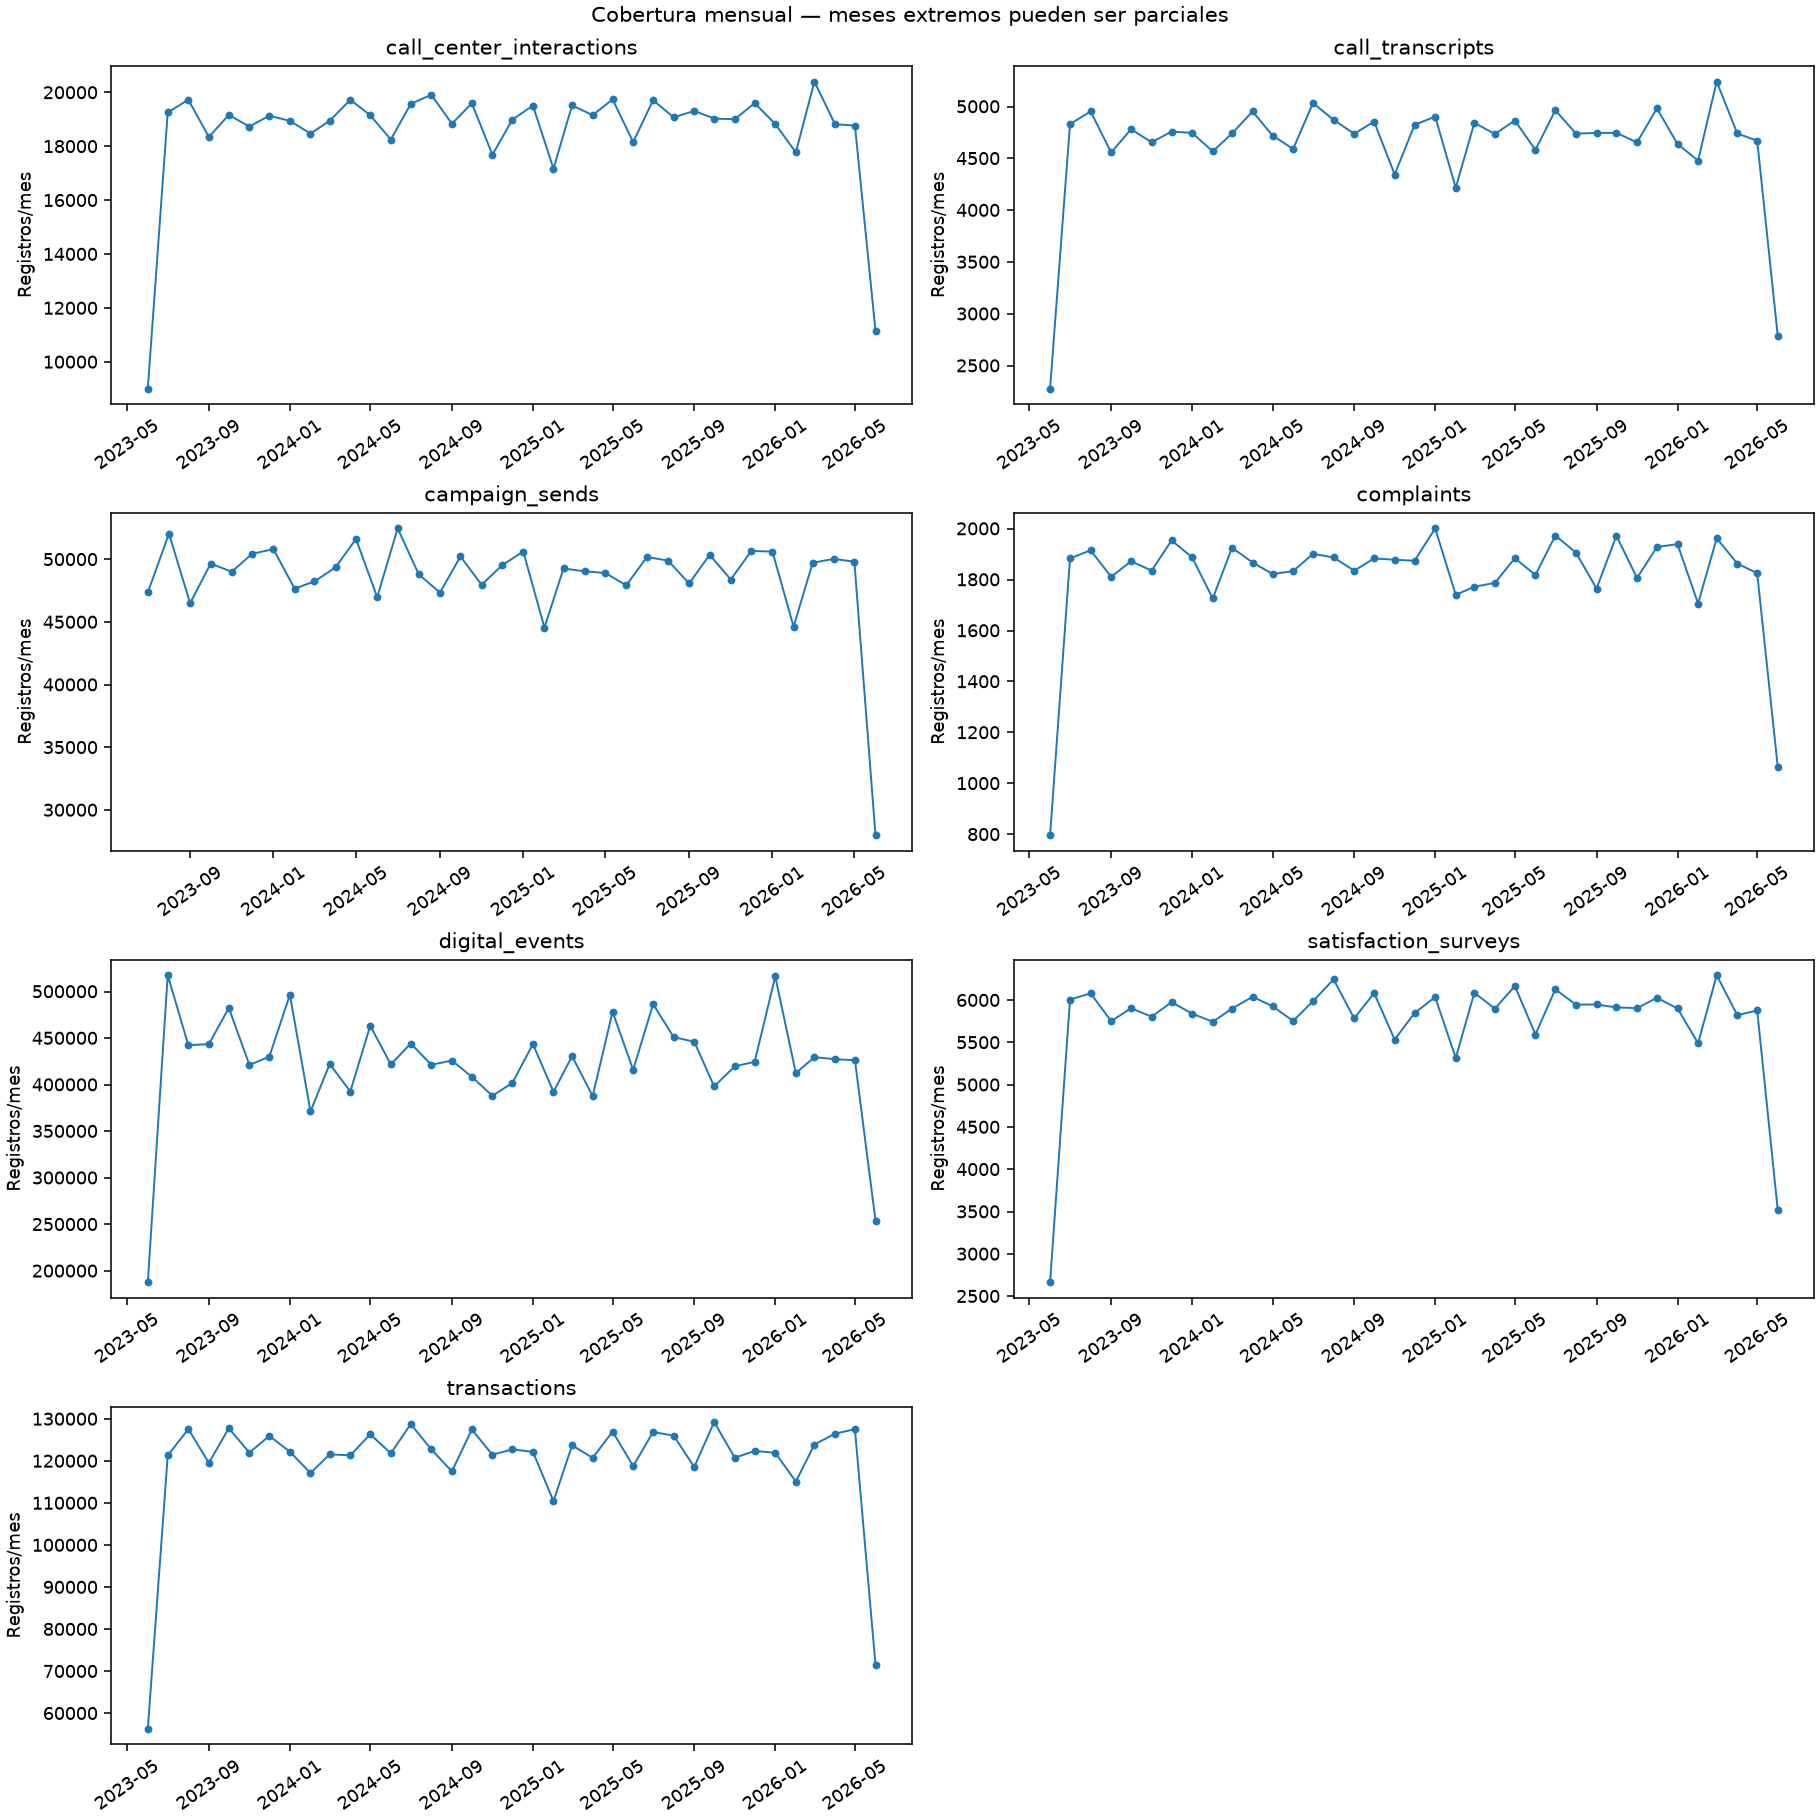

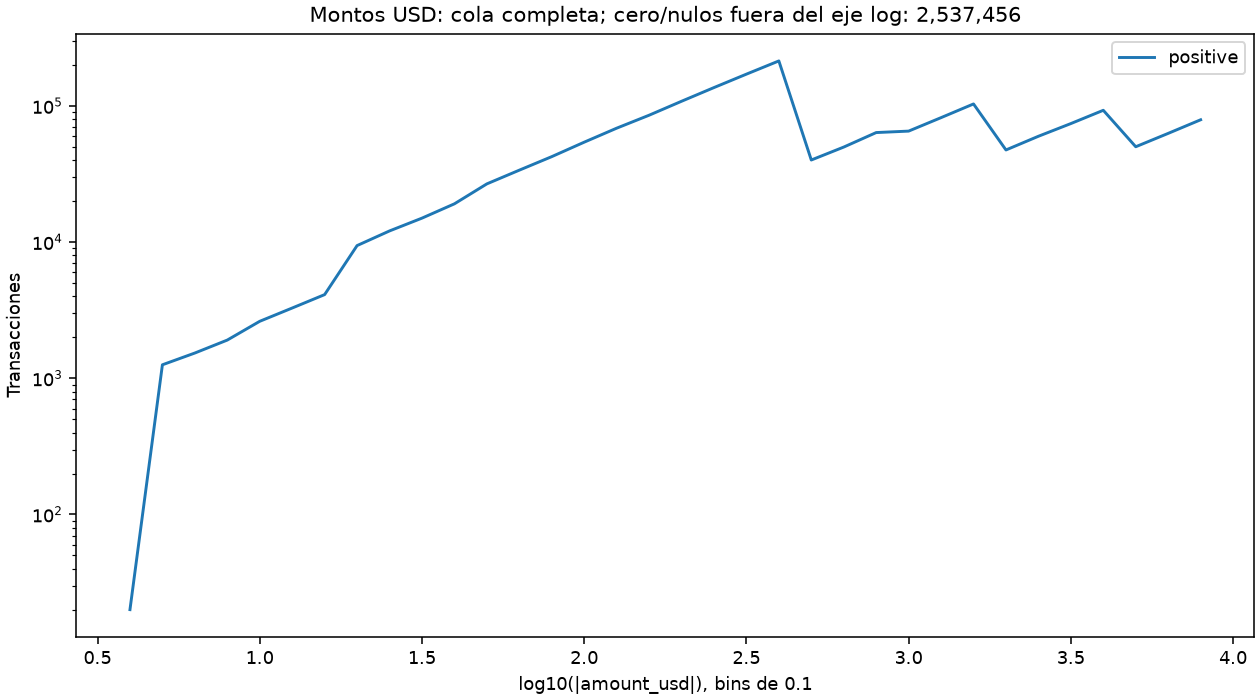

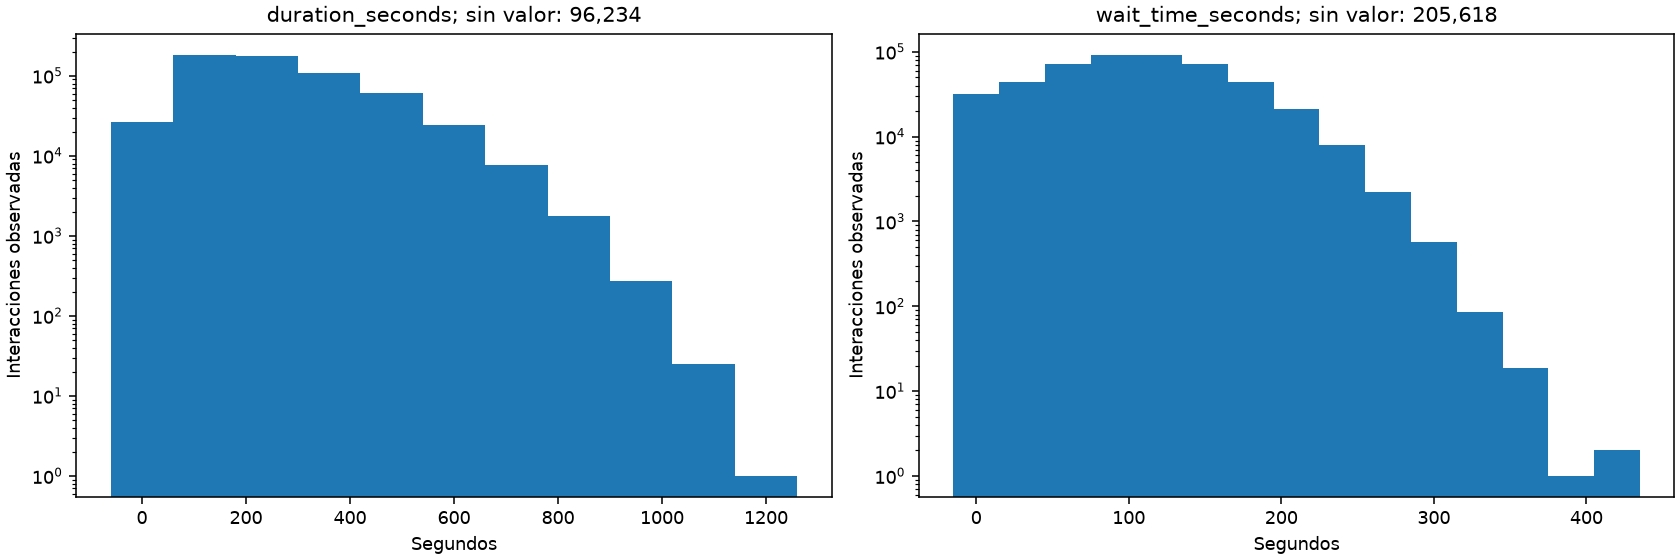

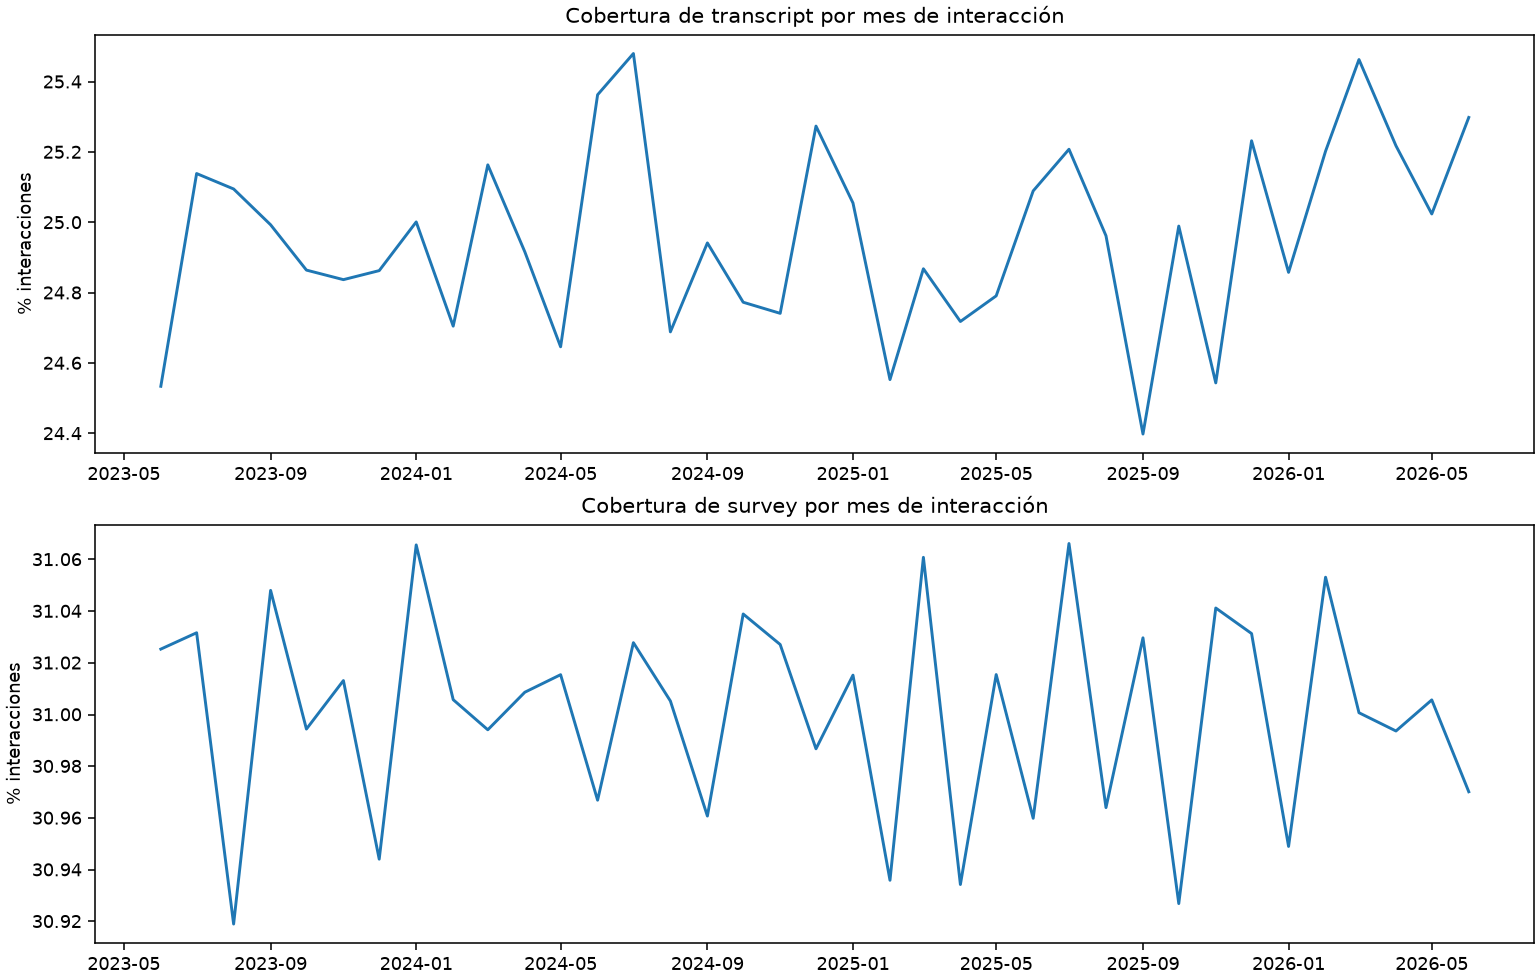

EDA completo; originales verificados SHA-256


**key_eda_metrics.csv**

,source,record,metric,value
0,semantic_validation.csv,0,validation,transaction_product_customer
1,semantic_validation.csv,0,total,4425008
2,semantic_validation.csv,0,eligible,4425008
3,semantic_validation.csv,0,linked,4425008
4,semantic_validation.csv,0,orphan,0
5,semantic_validation.csv,0,inconsistent,0
6,semantic_validation.csv,0,consistent,4425008
7,semantic_validation.csv,0,consistent_pct,100.0
8,semantic_validation.csv,1,validation,transcript_customer
9,semantic_validation.csv,1,total,171321


In [17]:
output.figures()
for name in ['monthly_coverage.png','amount_usd_distribution.png','service_duration_wait.png','selection_coverage.png']:
    display(Image(filename=str(FIG / name)))
output.findings(context)
finish(con, context)
show('key_eda_metrics.csv')

## EDA Findings & Implications for Customer Journey Discovery

### Confirmed findings

Resultados demostrados y limitaciones específicas se generan desde los artefactos ejecutados.

In [18]:
display(Markdown((OUT / 'EDA_FINDINGS.md').read_text()))

# EDA Findings & Implications for Customer Journey Discovery

## Confirmed findings

Ejecutado: 2026-10-01T00:43:28.375308-05:00. Corte de features: 2026-06-17 inclusive; edad referida a ese día.

### Coherencia semántica

| validation | total | eligible | consistent | inconsistent | orphan | consistent_pct |
| --- | --- | --- | --- | --- | --- | --- |
| transaction_product_customer | 4425008 | 4425008 | 4425008 | 0 | 0 | 100.0 |
| transcript_customer | 171321 | 171321 | 171321 | 0 | 0 | 100.0 |
| transcript_agent | 171321 | 171321 | 171321 | 0 | 0 | 100.0 |
| survey_customer | 212759 | 212759 | 212759 | 0 | 0 | 100.0 |
| survey_agent | 212759 | 212759 | 212759 | 0 | 0 | 100.0 |
| complaint_product_customer | 67095 | 44570 | 0 | 44570 | 0 | 0.0 |

Los IDs coincidentes no prueban coherencia de propietario/agente; las discrepancias anteriores se conservan y los ejemplos están seudonimizados en semantic_validation_examples.csv.

La relación affected_product_id de reclamos describe una referencia declarada; con propietario discordante no permite atribuir ese producto al cliente del reclamo.

### Horizonte observado

| dataset | basis | min_timestamp | max_timestamp | active_days | days_without_records |
| --- | --- | --- | --- | --- | --- |
| transactions | transaction_date | 2023-06-17 06:01:30 | 2026-06-18 05:59:41 | 1098 | 0 |
| digital_events | event_date | 2023-06-17 06:02:03 | 2026-06-18 06:04:05 | 1098 | 0 |
| call_center_interactions | interaction_date | 2023-06-17 08:03:26 | 2026-06-18 07:58:13 | 1098 | 0 |
| call_transcripts | process_date only; no independent event timestamp | 2023-06-17 00:00:00 | 2026-06-17 00:00:00 | 1097 | 0 |
| complaints | creation_date | 2023-06-17 08:07:05 | 2026-06-18 07:56:52 | 1098 | 0 |
| satisfaction_surveys | survey_date | 2023-06-17 09:29:20 | 2026-06-19 06:54:58 | 1099 | 0 |
| campaign_sends | send_date | 2023-07-01 06:00:42 | 2026-06-18 05:59:53 | 1084 | 0 |

Fechas posteriores de resolución/cierre/conversión se reportan en lifecycle_windows.csv. Las fechas nominales de proceso se comparan por día; sus horas calculadas contra medianoche no prueban latencia real.

### Clientes y transacciones

| variable | valid | median | p90 | p99 |
| --- | --- | --- | --- | --- |
| age | 150000 | 52.0 | 77.0 | 83.0 |
| credit_score | 127508 | 631.0 | 761.0 | 850.0 |

| variable | category | records | pct |
| --- | --- | --- | --- |
| country | México | 74907 | 49.938 |
| country | Colombia | 45251 | 30.167333333333332 |
| country | Argentina | 29842 | 19.894666666666666 |
| segment | Basic | 89756 | 59.83733333333333 |
| segment | Plus | 37547 | 25.031333333333333 |
| segment | Premium | 15207 | 10.138 |
| segment | Student | 7490 | 4.993333333333333 |

| variable | valid | minimum | median | p90 | p95 | p99 | maximum |
| --- | --- | --- | --- | --- | --- | --- | --- |
| amount_usd | 1887552 | 5.0 | 466.69 | 5113.063000000009 | 7554.503499999999 | 9506.714899999999 | 9999.96 |
| fraud_score | 3539851 | 0.0 | 15.01 | 27.02 | 28.52 | 29.72 | 99.99 |

| currency | transactions | amount_usd_observed | amount_usd_coverage_pct |
| --- | --- | --- | --- |
| USD | 2437979 | 0 | 0.0 |
| ARS | 792585 | 752544 | 94.94804973599047 |
| COP | 1194444 | 1135008 | 95.02396093914825 |

Los resúmenes de amount_usd describen exclusivamente valores observados. Las transacciones USD tienen amount_usd nulo en este extracto; amount se mantiene separado por moneda y no se rellena automáticamente amount_usd. Las features incluyen conteo y porcentaje monetario observado por cliente.

| variable | category | records | pct |
| --- | --- | --- | --- |
| transaction_type | Purchase | 1083406 | 24.48370714810007 |
| transaction_type | Withdrawal | 964673 | 21.800480360713472 |
| transaction_type | Transfer | 896438 | 20.258449250261243 |
| transaction_type | Payment | 738964 | 16.699721220842992 |
| transaction_type | Deposit | 609409 | 13.771929903855542 |
| transaction_type | Adjustment | 132118 | 2.9857121162266824 |
| channel | POS | 1548161 | 34.986626012879526 |
| channel | ATM | 1328334 | 30.0187931863626 |
| channel | Web | 663445 | 14.993080238499005 |
| channel | App | 663414 | 14.992379674793808 |
| channel | Branch | 132495 | 2.9942318748350285 |
| channel | Transfer | 89159 | 2.0148890126300336 |
| transaction_status | Approved | 4070681 | 91.99262464610233 |
| transaction_status | Declined | 221234 | 4.999629379201123 |
| transaction_status | Pending | 88343 | 1.9964483680029506 |
| transaction_status | Reversed | 44750 | 1.0112976066935924 |

Ingreso se presenta por país sin asumir moneda ni equivalencia internacional. Balances y límites se segmentan por moneda. Las categorías y altas por mes se encuentran en los CSV de cada dominio.

### Digital

| events | identified | anonymous | anonymous_pct | identified_customers | product_known_pct |
| --- | --- | --- | --- | --- | --- |
| 15620994 | 11875548 | 3745446 | 23.97700171960888 | 149997 | 9.220527195644529 |

| sessions | singleton_sessions | multi_customer_sessions | anonymous_only_sessions | mixed_identity_sessions |
| --- | --- | --- | --- | --- |
| 1837415 | 0 | 0 | 367044 | 498785 |

La duración de sesión es el intervalo entre el primer y último evento observado; un evento único implica intervalo cero, no duración real cero.

### Transcripts y surveys

| n_interactions | n_interactions_with_transcript | interaction_coverage_pct | n_calls | n_calls_with_transcript | call_coverage_pct |
| --- | --- | --- | --- | --- | --- |
| 686296 | 171321 | 24.96313544010165 | 583250 | 145577 | 24.95962280325761 |

| n_interactions | n_interactions_with_survey | interaction_coverage_pct | n_calls | n_calls_with_survey | call_coverage_pct |
| --- | --- | --- | --- | --- | --- |
| 686296 | 212759 | 31.001054938393928 | 583250 | 180908 | 31.017231033004716 |

| survey_type | valid | minimum | median | maximum |
| --- | --- | --- | --- | --- |
| CSAT | 127856 | 1.0 | 3.0 | 4.0 |
| NPS | 63668 | 2.0 | 6.0 | 7.0 |
| CES | 21235 | 1.0 | 3.0 | 4.0 |

Las tablas *_selection_numeric/categories/monthly.csv comparan ambos grupos. Diferencias descriptivas sugieren selección; semejanza en estas variables no demuestra ausencia de sesgo. CSAT, CES y NPS se mantienen separados; las features de satisfacción usan solo CSAT.

### Reclamos

| status | records | resolution_null_pct | closing_null_pct | origin_interaction_null |
| --- | --- | --- | --- | --- |
| Closed | 2609 | 5.366040628593331 | 4.906094288999617 | 2609 |
| Escalated | 3321 | 100.0 | 100.0 | 3321 |
| In Process | 26823 | 100.0 | 100.0 | 26823 |
| Open | 20125 | 100.0 | 100.0 | 20125 |
| Rejected | 705 | 100.0 | 100.0 | 705 |
| Resolved | 13512 | 4.677323860272351 | 100.0 | 13512 |

Los nulos se evalúan por estado. Los agregados temporales de resolución usan únicamente fechas <= corte; open_complaint_count queda NULL porque un estado snapshot no reconstruye el estado histórico. Se proporciona no_observed_resolution_by_cutoff_count como observación distinta, no como equivalencia a abierto.

### Campañas

| sent | delivered | opened | clicked | converted | strict_full_funnel | converted_without_clicked | converted_missing_date | nonconverted_with_date |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1746801 | 1642044 | 487309 | 97793 | 9799 | 9799 | 0 | 0 | 0 |

Los flags marginales y el funnel estricto se muestran por separado. NULL de fecha sin conversión no se clasifica como defecto. Moneda de conversion_value/send_cost no documentada: sumas en unidades originales, sin equipararlas a USD.

### Tipos de cambio

| currency | pair_direction | operation | matched | eligible_amounts | within_tolerance_pct | median_relative_error |
| --- | --- | --- | --- | --- | --- | --- |
| ARS | USD_to_currency | multiply | 792338 | 752317 | 0.0 | 122568.51628722929 |
| COP | USD_to_currency | multiply | 1194084 | 1134663 | 0.0 | 15986382.761916429 |
| ARS | currency_to_USD | multiply | 792338 | 752317 | 51.52149958062891 | 0.009735171246819344 |
| COP | currency_to_USD | multiply | 1194084 | 1134663 | 47.67882622417405 | 0.011988410494455159 |
| ARS | USD_to_currency | divide | 792338 | 752317 | 50.05802075454895 | 0.009984819767181317 |
| COP | USD_to_currency | divide | 1194084 | 1134663 | 47.4330263699442 | 0.010484445544214105 |
| ARS | currency_to_USD | divide | 792338 | 752317 | 0.0 | 122420.64650518577 |
| COP | currency_to_USD | divide | 1194084 | 1134663 | 0.0 | 16000042.104537986 |

Se contrastan ambas direcciones y fórmulas usando día calendario exacto, tolerancia max(0.02 USD, 1% de amount_usd). El ajuste empírico es evidencia de compatibilidad, no confirmación contractual de las unidades. No se corrigen montos ni se usan tasas de otro día.

### Asociaciones preliminares

| x | y | paired_customers | pearson_raw | spearman |
| --- | --- | --- | --- | --- |
| digital_event_count | interaction_count | 148436 | -0.0026958719886130016 | -0.002132703710436149 |
| transaction_count | complaint_count | 48806 | 0.006512509478587778 | 0.0022807940322665224 |
| complaint_count | avg_satisfaction | 31079 | 0.005953249288842751 | 0.005298072283931816 |
| median_wait_time | avg_satisfaction | 84728 | 0.0032376902282737676 | 0.0023181048480742936 |
| interaction_count | avg_satisfaction | 86087 | -0.0018535410339412057 | -0.013125350347184745 |

Solo clientes con ambas observaciones; ausencia de dominio permanece NULL. Estas asociaciones no son causales y pueden reflejar exposición, selección o claves incoherentes.

## Data limitations

- registration_branch_id y assigned_branch_id: relaciones no confiables según profiling; excluidas de joins geográficos.
- Reclamos sin origin_interaction_id; no existe enlace observado al contacto que los originó.
- Digital anónimo y product_id escaso; sesiones multi-cliente, si aparecen, requieren revisión antes de enlazar secuencias.
- Transcripts y encuestas tienen cobertura parcial; interacciones incluyen llamadas, chat, email y video.
- last_updated ambiguo; atributos de snapshot (saldo, segmento, income, score y estado) no entran en customer_360.
- No hay timestamps de disponibilidad/revisiones: features son agregados EDA a corte, no certificación de point-in-time para modelos.
- Meses/días extremos pueden ser parciales; cambios x2 o /2 son alertas de volumen, no errores automáticos.
- No se exporta texto personal; lengths/word counts son aproximaciones por caracteres/tokens de espacio.

## Hypotheses

- Explicar la discordancia reclamo-producto antes de interpretar propiedad y recorridos entre esos dominios.
- Investigar continuidad entre eventos anónimos e identificados dentro de sesiones mixtas, sin atribuirlos automáticamente en esta etapa.
- Investigar el calendario de proceso frente a eventos que cruzan medianoche; confirmar zona horaria y fecha operativa.
- Evaluar actividad digital y frecuencia de atención controlando exposición y selección.
- Examinar espera y CSAT dentro de canales/motivos comparables y con enlaces semánticamente válidos.
- Confirmar dirección/unidades FX y semántica de sesión con responsables de los datos.
- Determinar cómo representar reclamos sin interacción de origen, manteniendo enlaces hipotéticos separados.

Se detiene la etapa 02. No se ejecutan journeys, modelado, embeddings ni LLMs.


### Data limitations

Consultar el informe anterior: claves discordantes, cobertura parcial, fechas de proceso, snapshot de estados y atributos, monedas no documentadas y ausencia de enlaces de origen en complaints.

### Hypotheses

Las preguntas del informe se proponen para revisar en 03_customer_journey_discovery.ipynb. La ejecución termina aquí para revisión del EDA.